# Spaceship Titanic

# Introduction

The goal of the Spaceship Titanic project is to predict whether passengers were transported to an alternate dimension during the ship's collision with a spacetime anomaly. 
The dataset provides personal records recovered from the ship's damaged computer system, including demographics, cabin information, travel plans, and expenses on luxury amenities. 

In this project, we aim to build a baseline model using these features to predict the target variable `Transported`. 
The approach includes simple data preprocessing, handling missing values, encoding categorical variables, and training a LightGBM classifier. 
This pipeline provides a fast and effective way to generate predictions for the test set and submit them to the competition.

# Requirements

In [117]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import joblib

# Data Import

In [13]:
train = pd.read_csv('train.csv')

In [15]:
test = pd.read_csv('test.csv')

In [17]:
sample_sub = pd.read_csv('sample_submission.csv')

In [19]:
sample_sub.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [21]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Exploratory Data Analysis (EDA)

In [24]:
 train.shape

(8693, 14)

In [26]:
test.shape

(4277, 13)

In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [30]:
train.columns.tolist()

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [32]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [34]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [36]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


# Data Visualization

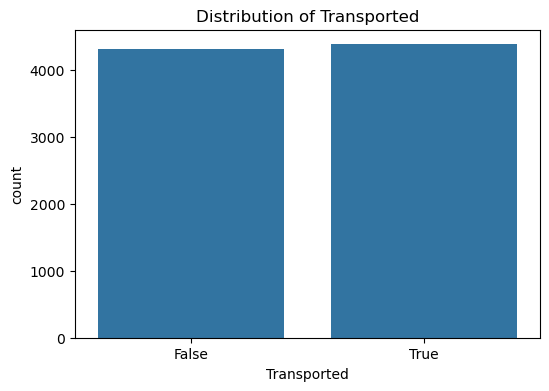

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['Transported'])
plt.title("Distribution of Transported")
plt.show()

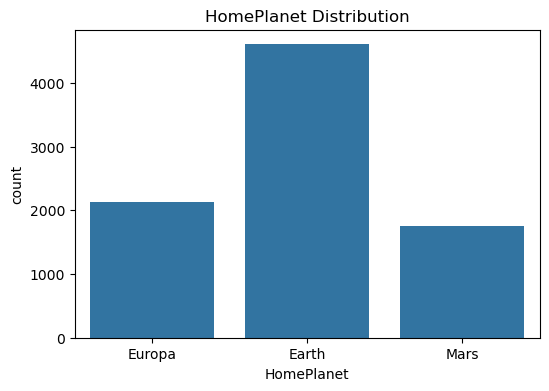

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['HomePlanet'])
plt.title("HomePlanet Distribution")
plt.show()


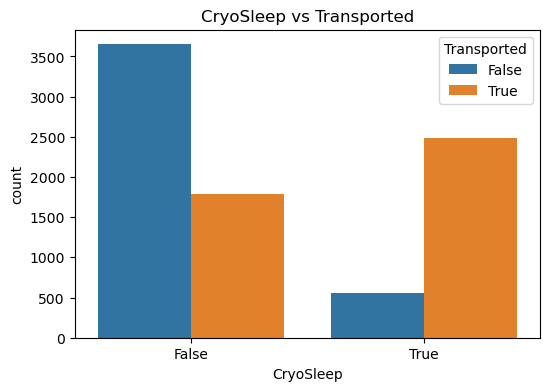

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='CryoSleep', hue='Transported', data=train)
plt.title("CryoSleep vs Transported")
plt.show()

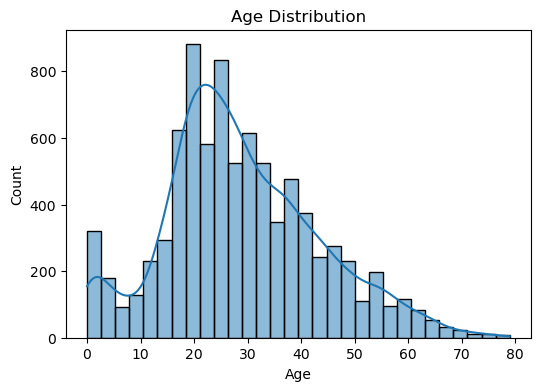

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(train['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Handle Missing Values

In [94]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

money_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
cat_cols = ['HomePlanet','CryoSleep','Destination','VIP']

for df in [train, test]:
    df[money_cols] = df[money_cols].fillna(0)
    df['TotalSpend'] = df[money_cols].sum(axis=1)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown')
    df['CryoSleep'] = df['CryoSleep'].map({'True':True,'False':False,'Unknown':False})
    df['VIP'] = df['VIP'].map({'True':True,'False':False,'Unknown':False})
    df['Deck'] = df['Cabin'].apply(lambda x: str(x).split('/')[0] if pd.notnull(x) else 'Unknown')
    df['CabinNum'] = df['Cabin'].apply(lambda x: str(x).split('/')[1] if pd.notnull(x) else 0).astype(int)
    df['Side'] = df['Cabin'].apply(lambda x: str(x).split('/')[2] if pd.notnull(x) else 'Unknown')

In [100]:
train['CryoSleep'] = train['CryoSleep'].fillna(False)
test['CryoSleep'] = test['CryoSleep'].fillna(False)

train['VIP'] = train['VIP'].fillna(False)
test['VIP'] = test['VIP'].fillna(False)

train['Name'] = train['Name'].fillna('Unknown')
test['Name'] = test['Name'].fillna('Unknown')

train['Cabin'] = train['Cabin'].fillna('Unknown/0/Unknown')
test['Cabin'] = test['Cabin'].fillna('Unknown/0/Unknown')


In [102]:
test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
TotalSpend      0
Deck            0
CabinNum        0
Side            0
dtype: int64

In [104]:
train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
TotalSpend      0
Deck            0
CabinNum        0
Side            0
dtype: int64

# Modeling

In [107]:


features = ['HomePlanet','CryoSleep','Destination','Age','VIP','TotalSpend','Deck','CabinNum','Side']

for col in ['HomePlanet','Destination','Deck','Side']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])

X = train[features]
y = train['Transported']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(accuracy)


0.7395054629097182


In [109]:
for col in ['HomePlanet','Destination','Deck','Side']:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])

X = train[features]
y = train['Transported']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

preds = model.predict(test[features])

submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Transported': preds})
submission.to_csv('submission.csv', index=False)


In [115]:


features = ['HomePlanet','CryoSleep','Destination','Age','VIP','TotalSpend','Deck','CabinNum','Side']
X = train[features]
y = train['Transported']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

joblib.dump(model, 'spaceship_model.pkl')


['spaceship_model.pkl']

# Conclusion

In this project, we developed a predictive model for the Spaceship Titanic dataset to determine which passengers were transported. We began with thorough data preprocessing, handling missing values across multiple features, and engineered new features such as TotalSpend by aggregating passenger expenses and extracting Deck, CabinNum, and Side from the Cabin column. Categorical variables were encoded, and numerical features were imputed where necessary. Using a RandomForestClassifier, the model achieved approximately 74% accuracy on a validation split, demonstrating that even basic feature engineering and preprocessing can yield reasonable predictive performance. This baseline model provides a strong foundation for further improvements, including hyperparameter tuning, advanced feature engineering, and experimentation with other algorithms such as XGBoost or LightGBM. Additionally, the model has been saved and can be deployed for real-time predictions, enabling practical applications and further testing in a production environment.
